In [34]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from matplotlib import pyplot as plt
import seaborn as sns

In [35]:
df = pd.read_csv('./results/cleaned_shipment_classification_dataset.csv')

In [36]:
# columns_to_drop = ['receipt_date', 'shipment_delay_days', 'shipment_terms','vessel__voyage',]
# df = df.drop(columns=columns_to_drop)

In [37]:
# df['payment_terms'] = df['payment_terms'].astype(str).str.lower().str.strip()

In [38]:
# --- 1️⃣ Copy dataframe ---
df_encoded = df.copy()

# --- 2️⃣ Encode binary column ---
df_encoded['inventory'] = df_encoded['inventory'].map({'Yes': 1, 'No': 0})

df_encoded['status'] = df_encoded['status'].map({'Active': 1, 'Inactive': 0})

# df_encoded['sale_account'] = df_encoded['sale_account'].map({'1410873000000000388': 1, '1410873000025511653	': 0})

# --- 3️⃣ Encode target column ---
df_encoded['shipment_classified'] = df_encoded['shipment_classified'].map({'on_time': 0, 'delayed': 1})

# --- 4️⃣ Convert date columns ---
date_columns = ['eta','due_date','bill_date','receipt_date']
for col in date_columns:
    df_encoded[col] = pd.to_datetime(df_encoded[col], errors='coerce')

# --- 5️⃣ Create derived time features ---
for col in date_columns:
  df_encoded[f'{col}_month'] = df_encoded['eta'].dt.month
  df_encoded[f'{col}_weekday'] = df_encoded['eta'].dt.weekday

df_encoded['shipment_duration'] = (pd.to_datetime(df_encoded['receipt_date']) - pd.to_datetime(df_encoded['bill_date'])).dt.days
# df['expected_delay'] = (pd.to_datetime(df['receipt_date']) - pd.to_datetime(df['eta'])).dt.days
df_encoded['due_gap'] = (pd.to_datetime(df_encoded['due_date']) - pd.to_datetime(df_encoded['bill_date'])).dt.days
# df['weekday_bill'] = pd.to_datetime(df['bill_date']).dt.weekday
# df['month_bill'] = pd.to_datetime(df['bill_date']).dt.month

# df_encoded['shipped_day'] = df_encoded['shipped_date'].dt.day
# df_encoded['shipped_month'] = df_encoded['shipped_date'].dt.month
# df_encoded['shipped_year'] = df_encoded['shipped_date'].dt.year
# df_encoded['shipped_weekday'] = df_encoded['shipped_date'].dt.weekday

# --- 6️⃣ Shipping delay feature ---
# df_encoded['delay_days'] = (df_encoded['eta'] - df_encoded['shipped_date']).dt.days

# # --- 7️⃣ Drop raw date columns ---
df_encoded.drop(date_columns, axis=1, inplace=True)

# these feature engineering cannot be applied due to high missing values
df_encoded['value_per_unit'] = df_encoded['purchase_price'] / df_encoded['quantity_in']
# df_encoded['profit_margin'] = (df_encoded['sales_price'] - df_encoded['purchase_price']) / df_encoded['purchase_price']
df_encoded['stock_after_shipment'] = df_encoded['opening_stock'] - df_encoded['quantity_in']


# --- 8️⃣ Handle categorical columns ---
categorical_cols = ['fda_status', 'coo', 'customs_broker', 'bill_status',
                   'bill_type', 'seal','consignee',
                    'tariff_type','brand', 'manufacturer','item_size',
                    'item_type']
from sklearn.preprocessing import LabelEncoder

for col in categorical_cols:
    if df_encoded[col].nunique() > 100:  
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    else:
        df_encoded = pd.get_dummies(df_encoded, columns=[col], drop_first=True, dtype=int)


# --- 9️⃣ Scale numeric features (optional for ML models like logistic regression) ---
# numeric_cols = ['discount', 'delay_days']
# scaler = StandardScaler()
# df_encoded[numeric_cols] = scaler.fit_transform(df_encoded[numeric_cols])

# # --- 🔟 Final encoded dataset ---
# print(df_encoded.head())

# X, y split for training
X = df_encoded.drop('shipment_classified', axis=1)
y = df_encoded['shipment_classified']


In [39]:
# Step 2: Data preprocessing
# df['inventory'] = df['inventory'].map({'Yes': 1, 'No': 0})
# df['shipment_classified'] = df['shipment_classified'].map({'on_time': 0, 'delayed': 1})

In [40]:
# Encode categorical columns
# cat_cols = df.select_dtypes(include=['object']).columns
# le = LabelEncoder()
# for col in cat_cols:
#     df[col] = le.fit_transform(df[col])

In [41]:
df_encoded

,quantity_in,seal,inventory,ocean_freight,purchase_price,sales_price,opening_stock,item_cases,brand,sales_account,...,manufacturer_SQUID,manufacturer_SWAI,manufacturer_TILAPIA,manufacturer_TROUT,manufacturer_VANNAMEI,manufacturer_WHITE SHRIMP,manufacturer_WHITING,manufacturer_WILD CAUGHT,manufacturer_YELLOW TAIL SNAPPER,manufacturer_unknown
0,35000.0,12306,1,4000.0,0.0,0.0,9280.0,1,7,1410873000000000388,...,0,0,0,0,1,0,0,0,0,0
1,35300.0,12292,1,4500.0,0.0,0.0,0.0,1,66,1410873000000000388,...,0,0,0,0,1,0,0,0,0,0
2,4200.0,15660,1,0.0,0.0,0.0,0.0,1,200,1410873000025511653,...,0,0,1,0,0,0,0,0,0,0
3,500.0,19365,1,0.0,0.0,0.0,0.0,1,66,1410873000000000388,...,0,0,0,0,0,0,0,1,0,0
4,6355.0,19365,1,0.0,0.0,0.0,0.0,1,66,1410873000000000388,...,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35519,31200.0,12385,0,0.0,0.0,0.0,0.0,1,114,1410873000000000388,...,0,0,0,0,1,0,0,0,0,0
35520,30600.0,376,0,0.0,0.0,0.0,0.0,0,189,1410873000000000388,...,0,0,0,0,1,0,0,0,0,0
35521,30600.0,4388,0,0.0,0.0,0.0,0.0,0,189,1410873000000000388,...,0,0,0,0,1,0,0,0,0,0
35522,29880.0,858,0,0.0,0.0,0.0,0.0,1,189,1410873000000000388,...,0,0,0,0,1,0,0,0,0,0


In [42]:
# # Step 3: Split features & target
# X = df.drop('shipment_classified', axis=1)
# y = df['shipment_classified']

In [43]:
# Step 4: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [44]:
X_train

,quantity_in,seal,inventory,ocean_freight,purchase_price,sales_price,opening_stock,item_cases,brand,sales_account,...,manufacturer_SQUID,manufacturer_SWAI,manufacturer_TILAPIA,manufacturer_TROUT,manufacturer_VANNAMEI,manufacturer_WHITE SHRIMP,manufacturer_WHITING,manufacturer_WILD CAUGHT,manufacturer_YELLOW TAIL SNAPPER,manufacturer_unknown
30443,36000.0,15010,0,0.0,0.0,0.0,0.0,1,146,1410873000000000388,...,0,0,0,0,1,0,0,0,0,0
31181,36000.0,3841,0,0.0,0.0,0.0,0.0,1,146,1410873000000000388,...,0,0,0,0,1,0,0,0,0,0
26152,5500.0,16569,0,0.0,0.0,0.0,0.0,1,48,1410873000000000388,...,0,0,0,0,1,0,0,0,0,0
33390,9600.0,7393,0,0.0,0.0,0.0,0.0,1,193,1410873000000000388,...,0,0,0,0,1,0,0,0,0,0
4853,36000.0,469,1,0.0,0.0,0.0,34440.0,1,190,1410873000000000388,...,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20925,22800.0,2353,0,0.0,0.0,0.0,0.0,1,7,1410873000000000388,...,0,0,0,0,1,0,0,0,0,0
18509,11600.0,19,1,0.0,0.0,0.0,0.0,1,44,1410873000000000388,...,0,0,0,0,1,0,0,0,0,0
11099,2550.0,19365,1,0.0,0.0,0.0,0.0,1,66,1410873000000000388,...,0,0,0,0,0,0,0,1,0,0
19345,8000.0,12389,1,0.0,0.0,0.0,0.0,1,200,1410873000025511653,...,0,0,1,0,0,0,0,0,0,0


In [45]:
# Step 5: Scale features
# scaler = StandardScaler()
# X_train = scaler.fit_transform(X_train)
# X_test = scaler.transform(X_test)

In [46]:
# Step 6: Train model
model = SVC(kernel='rbf', C=1.0, gamma='scale', class_weight='balanced')
model.fit(X_train, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,'balanced'
,verbose,False


In [47]:
# Step 7: Evaluate
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.8412460123850629

Confusion Matrix:
 [[8966    0]
 [1692    0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.84      1.00      0.91      8966
           1       0.00      0.00      0.00      1692

    accuracy                           0.84     10658
   macro avg       0.42      0.50      0.46     10658
weighted avg       0.71      0.84      0.77     10658



/Users/prashant/.pyenv/versions/ideabox-env/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/prashant/.pyenv/versions/ideabox-env/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/prashant/.pyenv/versions/ideabox-env/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [48]:
# import pandas as pd

# # For linear SVM only
# coeff = model.coef_.ravel()  
# importance = pd.Series(coeff, index=X.columns).sort_values(key=abs, ascending=False)

# print("\nTop features influencing delay:\n", importance.head(10))


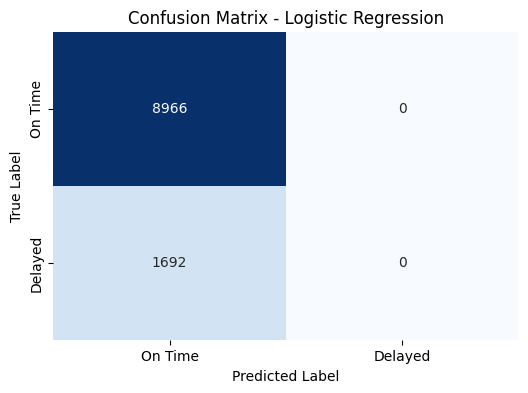

In [49]:
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['On Time', 'Delayed'],
            yticklabels=['On Time', 'Delayed'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()